# uxarray-mcp 0.2 — What's New (Visual Demo)

A single, self-contained, **plot-rich** tour of everything in the two recent
changes:

- **PR #64 (Peng / toolregistry-server 0.4.0)** — the new `App` /
  `ServerIdentity` foundation and the brand-new **OpenAPI / REST** surface
  (`uxarray-mcp openapi`). `server.py` is gone; `make_registry` and
  `make_mcp_server` now live in `uxarray_mcp.app`.
- **PR #65 (post-toolregistry follow-ups)** — UXarray **2026.6.0** plus a
  batch of new `run_analysis` operations (vector calculus, model
  verification, climatology/anomaly, rectilinear remap, zonal anomaly) and
  four new guided **science-workflow prompts**.

This notebook is **deterministic** — it drives the same functions an MCP/AI
client calls, directly from Python. No LLM, no gateway, no MCP transport
required. Every scientific result below is also **plotted inline**.

In [1]:
import base64
import io
import json
import os
import tempfile

import matplotlib

matplotlib.use("Agg")  # render figures to PNG bytes; we display them explicitly
import matplotlib.pyplot as plt
import numpy as np
import uxarray as ux
import xarray as xr
from IPython.display import Image, display

import uxarray_mcp

plt.rcParams["figure.dpi"] = 110
print("uxarray-mcp :", uxarray_mcp.__version__)
print("uxarray     :", ux.__version__)


def show(title, result, drop=("_provenance",)):
    """Compact JSON view of a tool result, hiding noisy keys."""
    print(f"=== {title} ===")
    print(
        json.dumps(
            {k: v for k, v in result.items() if k not in drop}, indent=2, default=str
        )
    )
    print()


def show_png(items, caption=None):
    """Decode + display the base64 PNG returned by a plotting tool."""
    png = base64.b64decode(items[0].data)
    if caption:
        print(f"{caption}  ({len(png):,} bytes)")
    display(Image(data=png))


def show_fig(fig):
    """Render a matplotlib figure to PNG and display it inline (deterministic)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))

uxarray-mcp : 0.2.0
uxarray     : 2026.6.0


## 0. Synthesize a realistic mesh + data

No sample data ships with the repo, so we build a global structured→
unstructured UGRID mesh (5° resolution) and put a **physically-suggestive**
field on it: a warm tropics that cools toward the poles, with a zonal wave —
so the science plots below actually look like atmospheric fields. We also
create a model/obs pair and a 24-step time series.

In [2]:
work = tempfile.mkdtemp(prefix="uxmcp_demo_")
GRID = os.path.join(work, "grid.nc")
DATA = os.path.join(work, "data.nc")
MODEL = os.path.join(work, "model.nc")
OBS = os.path.join(work, "obs.nc")
TS = os.path.join(work, "timeseries.nc")

lon = np.arange(0, 360, 5.0)
lat = np.arange(-87.5, 88, 5.0)
grid = ux.Grid.from_structured(lon=lon, lat=lat)
grid.to_xarray().to_netcdf(GRID)
n = grid.n_face

flon = np.asarray(grid.face_lon)
flat = np.asarray(grid.face_lat)

# Temperature: warm equator, cool poles, + a zonal wave-3 pattern
temperature = (
    300 - 40 * np.sin(np.radians(flat)) ** 2 + 5 * np.cos(np.radians(3 * flon))
)
# Wind: westerlies that vary with latitude + a meridional wave
u_wind = 20 * np.cos(np.radians(flat)) + 5 * np.sin(np.radians(2 * flon))
v_wind = 8 * np.sin(np.radians(2 * flat)) * np.cos(np.radians(flon))

xr.Dataset(
    {
        "temperature": (["n_face"], temperature),
        "u": (["n_face"], u_wind),
        "v": (["n_face"], v_wind),
    }
).to_netcdf(DATA)

rng = np.random.default_rng(0)
# Model = truth + small noise; Obs = truth (so metrics are meaningful)
xr.Dataset({"temperature": (["n_face"], temperature + rng.normal(0, 2, n))}).to_netcdf(
    MODEL
)
xr.Dataset({"temperature": (["n_face"], temperature)}).to_netcdf(OBS)

nt = 24
t = np.arange(nt)
series = (
    temperature[None, :]
    + 10 * np.sin(2 * np.pi * t / 12)[:, None]
    + rng.normal(0, 1, (nt, n))
)
xr.Dataset({"temperature": (["time", "n_face"], series)}, coords={"time": t}).to_netcdf(
    TS
)

print(f"mesh: {n} faces @ 5deg | model/obs pair | {nt}-step time series")

mesh: 2592 faces @ 5deg | model/obs pair | 24-step time series


---
# Part 1 — PR #64: the `App` / `ServerIdentity` foundation

Peng's 0.4.0 refactor consolidated all server wiring into `uxarray_mcp.app`.
One `ServerIdentity` drives the MCP server name, the OpenAPI title, and the
CLI banner. The same tool surface can now be served over **MCP *or*
OpenAPI/REST** — that REST surface is the headline new capability.

In [3]:
from uxarray_mcp.app import UXARRAY_IDENTITY, UXarrayApp, make_mcp_server, make_registry

print("identity   :", UXARRAY_IDENTITY.name, "v" + UXARRAY_IDENTITY.version)
print("description:", UXARRAY_IDENTITY.description)

reg = make_registry(profile="core")
print(f"\ncore profile exposes {len(reg.list_tools())} tools")

server = make_mcp_server(profile="core")
print("MCP server name:", server.name)

app = UXarrayApp()
print("App serve methods:", [m for m in dir(app) if m.startswith("serve")])
print(
    "\nDeployment (these block, so not called here):\n"
    "  uxarray-mcp serve   --transport stdio          # MCP (Claude Desktop)\n"
    "  uxarray-mcp serve   --transport streamable-http # remote MCP\n"
    "  uxarray-mcp openapi --port 8000                # NEW: REST / OpenAPI"
)

2026-06-25 01:32:44.126 | INFO     | MCP server 'UXarray MCP' created with 31 enabled tool(s) out of 31 total


identity   : UXarray MCP v0.2.0
description: Mesh analysis tools for AI agents

core profile exposes 31 tools
MCP server name: UXarray MCP
App serve methods: ['serve', 'serve_mcp', 'serve_openapi']

Deployment (these block, so not called here):
  uxarray-mcp serve   --transport stdio          # MCP (Claude Desktop)
  uxarray-mcp serve   --transport streamable-http # remote MCP
  uxarray-mcp openapi --port 8000                # NEW: REST / OpenAPI


## 1.1 The tool surface, visualized

A quick bar chart of how the `core` and `deferred-full` profiles break down.

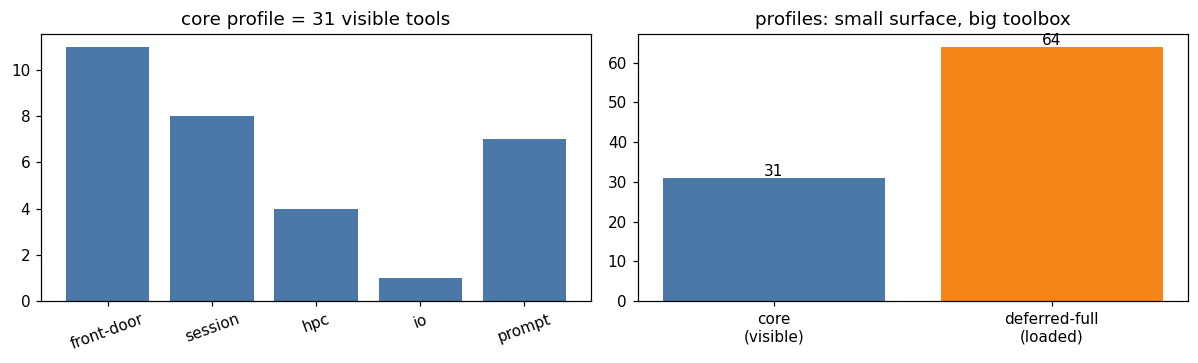

In [4]:
core_tools = make_registry(profile="core").list_tools()
full = make_registry(profile="deferred-full")
full_tools = full.list_tools()

# group core tools by namespace prefix
groups: dict[str, int] = {}
for tname in core_tools:
    ns = (
        tname.split("-")[0].split("/")[0]
        if any(s in tname for s in ("-", "/"))
        else "front-door"
    )
    ns = ns if ns in ("session", "hpc", "io", "prompt") else "front-door"
    groups[ns] = groups.get(ns, 0) + 1

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.bar(list(groups), list(groups.values()), color="#4c78a8")
a1.set_title(f"core profile = {len(core_tools)} visible tools")
a1.tick_params(axis="x", rotation=20)
a2.bar(
    ["core\n(visible)", "deferred-full\n(loaded)"],
    [len(core_tools), len(full_tools)],
    color=["#4c78a8", "#f58518"],
)
a2.set_title("profiles: small surface, big toolbox")
for i, vv in enumerate([len(core_tools), len(full_tools)]):
    a2.text(i, vv + 0.5, str(vv), ha="center")
fig.tight_layout()
show_fig(fig)

## 1.2 Simulating a REST request — no AI, no HTTP server

The OpenAPI front end receives JSON, looks up the tool, calls it. Here is
that exact flow — swap `incoming` for an HTTP body and you have the
`uxarray-mcp openapi` surface.

In [5]:
incoming = {
    "tool": "run_analysis",
    "args": {"operation": "calculate_area", "grid_path": GRID},
}
response = reg.get_callable(incoming["tool"])(**incoming["args"])
show("REST-style run_analysis(calculate_area)", response)

=== REST-style run_analysis(calculate_area) ===
{
  "total_area": 12.566370620541452,
  "mean_area": 0.0048481368134804985,
  "min_area": 0.00033165631249057627,
  "max_area": 0.007610567087478754,
  "area_units": "m^2",
  "n_face": 2592,
  "recommended_next_steps": [
    "plot_mesh(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc\")",
    "inspect_variable(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc\", \"<data_path>\")",
    "calculate_zonal_mean(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc\", \"<data_path>\", \"<variable_name>\")"
  ]
}



---
# Part 2 — PR #65: new `run_analysis` operations, plotted

Every new computation is reachable through the single front-door
`run_analysis(operation=..., ...)` dispatcher. Below, each result is shown
*and* visualized. For mesh maps of derived fields we render through the
package's own `plot_dataset` tool (the same base64-PNG path MCP/REST use).

In [6]:
run_analysis = reg.get_callable("run_analysis")
plot_dataset = reg.get_callable("plot_dataset")
uxds = ux.open_dataset(GRID, DATA)  # for extracting derived fields to map


def map_field(values, name, cmap="viridis", caption=None):
    """Write a face-centered field to disk and render it via plot_dataset."""
    path = os.path.join(work, f"{name}.nc")
    xr.Dataset({name: (["n_face"], np.asarray(values))}).to_netcdf(path)
    items = plot_dataset(
        plot_type="variable",
        grid_path=GRID,
        data_path=path,
        variable_name=name,
        cmap=cmap,
    )
    show_png(items, caption or name)

### The input field — temperature on the unstructured mesh

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

temperature (input field)  (23,814 bytes)


/Users/mbook/uxarray-mcp-server/src/uxarray_mcp/domain/plotting.py:428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


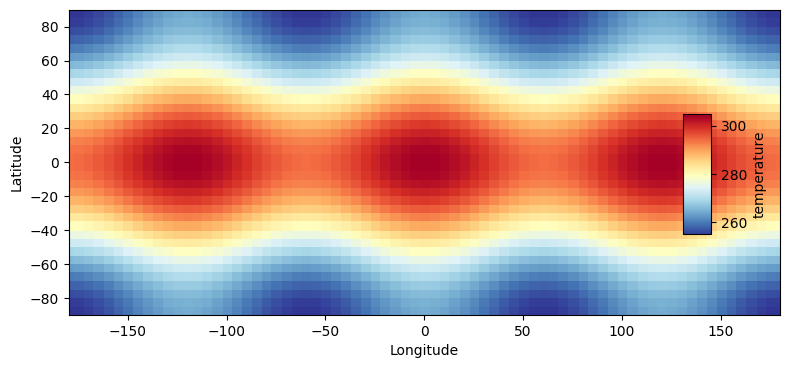

In [7]:
show_png(
    plot_dataset(
        plot_type="variable",
        grid_path=GRID,
        data_path=DATA,
        variable_name="temperature",
        cmap="RdYlBu_r",
    ),
    "temperature (input field)",
)

## 2.1 Vector calculus — gradient magnitude

Green-Gauss finite-volume gradient. We map the **magnitude** of the gradient
(where the field changes fastest — fronts and edges light up).

=== gradient(temperature) — stats ===
{
  "variable_name": "temperature",
  "components": [
    "zonal_gradient",
    "meridional_gradient"
  ],
  "component_stats": {
    "zonal_gradient": {
      "min": -453.8350746939204,
      "max": 453.83507469392043,
      "mean": -0.45639012240328924
    },
    "meridional_gradient": {
      "min": -157.70950822605948,
      "max": 157.7095082260619,
      "mean": 4.646830072923868e-13
    }
  },
  "n_face": 2592,
  "scale_by_radius": false,
  "interpretation": "zonal (\u2202/\u2202x) and meridional (\u2202/\u2202y) components of the gradient"
}



/Users/mbook/uxarray-mcp-server/.venv/lib/python3.12/site-packages/uxarray/core/dataarray.py:1514: UserWarning: scale_by_radius=True but the grid has no 'sphere_radius' attribute; result is left on the unit sphere. Set uxgrid.sphere_radius or pass scale_by_radius=False.
  grad_zonal_da, grad_meridional_da = _compute_gradient(


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

|∇ temperature| — sharp gradients highlighted  (21,729 bytes)


/Users/mbook/uxarray-mcp-server/src/uxarray_mcp/domain/plotting.py:428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


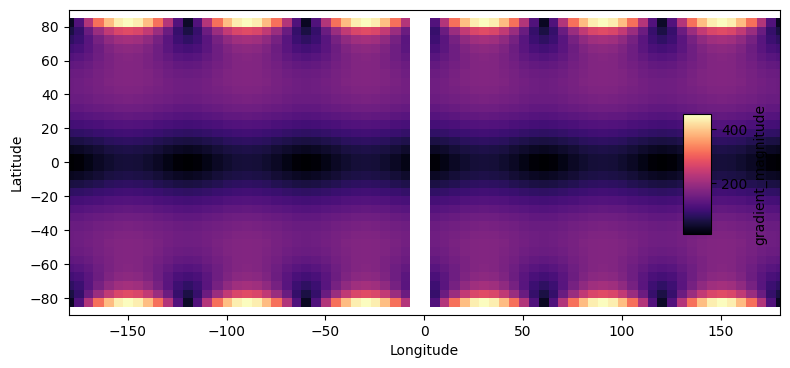

In [8]:
g = run_analysis(
    operation="gradient", grid_path=GRID, data_path=DATA, variable_name="temperature"
)
show("gradient(temperature) — stats", g)

gfield = uxds["temperature"].gradient()
grad_mag = np.hypot(
    np.asarray(gfield["zonal_gradient"].values),
    np.asarray(gfield["meridional_gradient"].values),
)
map_field(
    grad_mag,
    "gradient_magnitude",
    cmap="magma",
    caption="|∇ temperature| — sharp gradients highlighted",
)

## 2.2 Curl — relative vorticity of the wind

ζ = ∂v/∂x − ∂u/∂y. Red = cyclonic, blue = anticyclonic.

=== curl / relative vorticity — stats ===
{
  "u_variable": "u",
  "v_variable": "v",
  "interpretation": "relative vorticity \u03b6 = \u2202v/\u2202x \u2212 \u2202u/\u2202y",
  "n_face": 2592,
  "scale_by_radius": false,
  "stats": {
    "min": -141.2119843055746,
    "max": 141.21198430558087,
    "mean": -1.8342750287857377e-14,
    "std": 62.518794815296616
  }
}



/Users/mbook/uxarray-mcp-server/.venv/lib/python3.12/site-packages/uxarray/core/dataarray.py:1593: UserWarning: scale_by_radius=True but the grid has no 'sphere_radius' attribute; result is left on the unit sphere. Set uxgrid.sphere_radius or pass scale_by_radius=False.
  grad_u_zonal, grad_u_meridional = _compute_gradient(
/Users/mbook/uxarray-mcp-server/.venv/lib/python3.12/site-packages/uxarray/core/dataarray.py:1596: UserWarning: scale_by_radius=True but the grid has no 'sphere_radius' attribute; result is left on the unit sphere. Set uxgrid.sphere_radius or pass scale_by_radius=False.
  grad_v_zonal, grad_v_meridional = _compute_gradient(


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

relative vorticity ζ = ∂v/∂x − ∂u/∂y  (21,930 bytes)


/Users/mbook/uxarray-mcp-server/src/uxarray_mcp/domain/plotting.py:428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


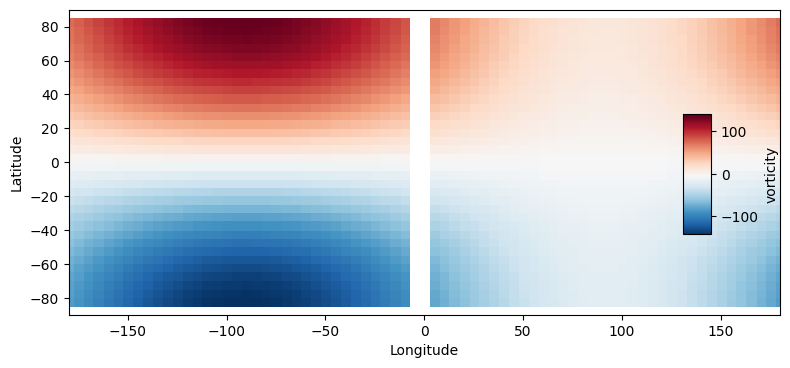

In [9]:
c = run_analysis(
    operation="curl", grid_path=GRID, data_path=DATA, u_variable="u", v_variable="v"
)
show("curl / relative vorticity — stats", c)

vort = uxds["u"].curl(uxds["v"])
map_field(
    vort.values,
    "vorticity",
    cmap="RdBu_r",
    caption="relative vorticity ζ = ∂v/∂x − ∂u/∂y",
)

## 2.3 Divergence of the wind field

∂u/∂x + ∂v/∂y — convergence (blue) vs divergence (red).

=== divergence — stats ===
{
  "u_variable": "u",
  "v_variable": "v",
  "interpretation": "horizontal divergence \u2202u/\u2202x + \u2202v/\u2202y",
  "n_face": 2592,
  "stats": {
    "min": -305.1350358333875,
    "max": 364.97411829107784,
    "mean": -2.4583631026291215,
    "std": 80.7961875370858
  }
}



/Users/mbook/uxarray-mcp-server/.venv/lib/python3.12/site-packages/uxarray/core/dataarray.py:1514: UserWarning: scale_by_radius=True but the grid has no 'sphere_radius' attribute; result is left on the unit sphere. Set uxgrid.sphere_radius or pass scale_by_radius=False.
  grad_zonal_da, grad_meridional_da = _compute_gradient(


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

wind divergence ∂u/∂x + ∂v/∂y  (23,409 bytes)


/Users/mbook/uxarray-mcp-server/src/uxarray_mcp/domain/plotting.py:428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


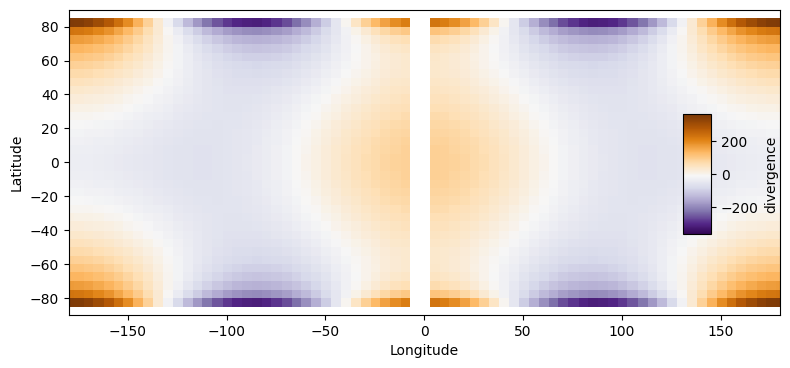

In [10]:
d = run_analysis(
    operation="divergence",
    grid_path=GRID,
    data_path=DATA,
    u_variable="u",
    v_variable="v",
)
show("divergence — stats", d)

div = uxds["u"].divergence(uxds["v"]) if hasattr(uxds["u"], "divergence") else None
if div is not None:
    map_field(
        div.values, "divergence", cmap="PuOr_r", caption="wind divergence ∂u/∂x + ∂v/∂y"
    )

## 2.4 Azimuthal mean — radial profile about a point

Great-circle-distance rings about `(center_lon, center_lat)` — the heart of
the cyclone-structure workflow (radius of max wind, etc).

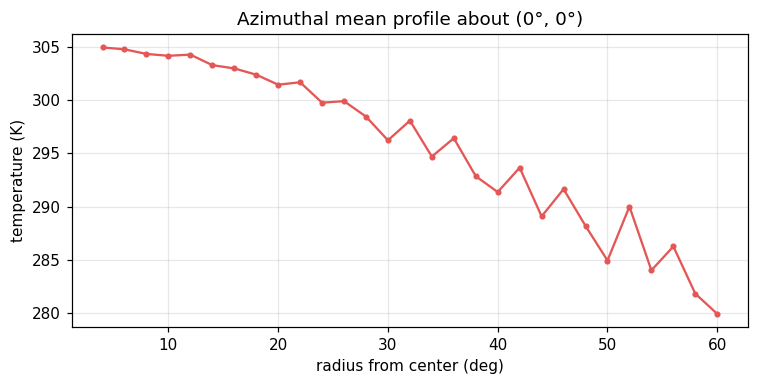

In [11]:
az = run_analysis(
    operation="azimuthal_mean",
    grid_path=GRID,
    data_path=DATA,
    variable_name="temperature",
    center_lon=0.0,
    center_lat=0.0,
    outer_radius=60.0,
    radius_step=2.0,
)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(az["radii_deg"], az["azimuthal_mean_values"], "-o", ms=3, color="#e45756")
ax.set_xlabel("radius from center (deg)")
ax.set_ylabel("temperature (K)")
ax.set_title("Azimuthal mean profile about (0°, 0°)")
ax.grid(alpha=0.3)
fig.tight_layout()
show_fig(fig)

## 2.5 Zonal anomaly — departure from the latitude-band mean

Per-face value minus the zonal mean of its latitude band — the eddy / wave
field used in storm-track diagnostics.

=== zonal_anomaly — stats ===
{
  "variable_name": "temperature",
  "conservative": false,
  "n_face": 2592,
  "stats": {
    "min": -6.743113286399307,
    "max": 6.743113286399421,
    "mean": 1.574597790974543e-14,
    "std": 3.744225604459493
  },
  "interpretation": "per-face deviation from the zonal mean of its latitude band",
  "grid_info": {
    "n_face": 2592,
    "n_node": 2701,
    "n_edge": 5292
  }
}



<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

temperature − zonal mean (wave structure)  (23,873 bytes)


/Users/mbook/uxarray-mcp-server/src/uxarray_mcp/domain/plotting.py:428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


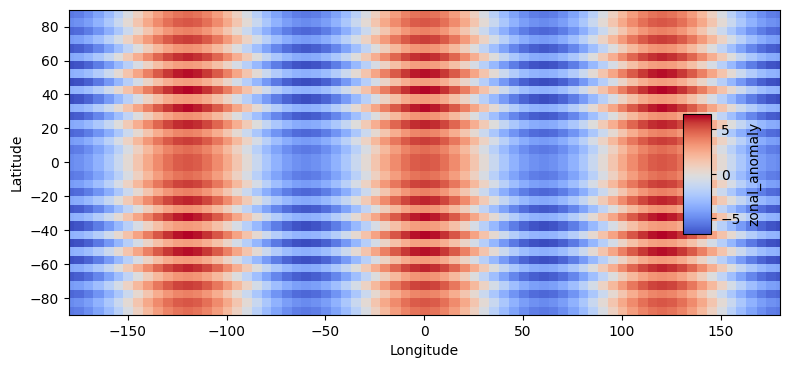

In [12]:
za = run_analysis(
    operation="zonal_anomaly",
    grid_path=GRID,
    data_path=DATA,
    variable_name="temperature",
)
show("zonal_anomaly — stats", za)

anom_field = uxds["temperature"].zonal_anomaly()
map_field(
    anom_field.values,
    "zonal_anomaly",
    cmap="coolwarm",
    caption="temperature − zonal mean (wave structure)",
)

## 2.6 Model verification — bias, RMSE, pattern correlation

Compare two fields on the same grid (model vs observations).

{
  "bias": -0.05773364051794611,
  "rmse": 1.9974568405086857,
  "pattern_correlation": 0.9907914179463436
}


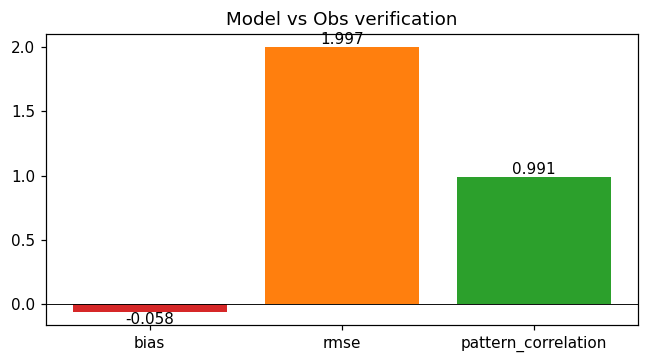

In [13]:
metrics = {}
for op in ("bias", "rmse", "pattern_correlation"):
    r = run_analysis(
        operation=op,
        grid_path=GRID,
        data_path_a=MODEL,
        data_path_b=OBS,
        variable_name="temperature",
    )
    metrics[op] = r[op]
print(json.dumps(metrics, indent=2))

fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(
    list(metrics), list(metrics.values()), color=["#d62728", "#ff7f0e", "#2ca02c"]
)
ax.set_title("Model vs Obs verification")
ax.axhline(0, color="k", lw=0.6)
for b, v in zip(bars, metrics.values()):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v,
        f"{v:.3f}",
        ha="center",
        va="bottom" if v >= 0 else "top",
    )
fig.tight_layout()
show_fig(fig)

## 2.7 Climatology + anomaly — needs a time dimension

`temporal_mean` collapses the time axis; `anomaly` subtracts that
climatology. We plot the domain-mean time series with the climatology line.

temporal_mean summary: {
  "dims": [
    "n_face"
  ],
  "shape": [
    2592
  ],
  "dtype": "float64",
  "name": "temperature",
  "min": 254.6524055339179,
  "max": 305.2612837858555,
  "mean": 279.99338020977376
}


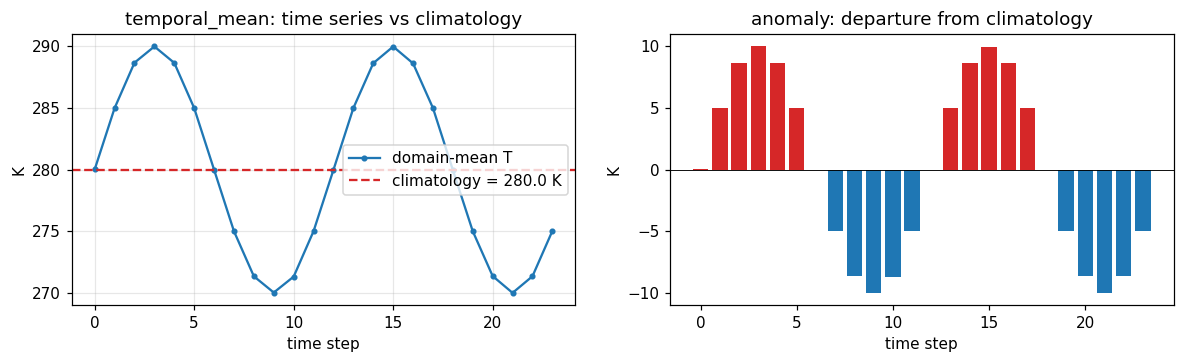

In [14]:
tm = run_analysis(operation="temporal_mean", data_path=TS, variable_name="temperature")
an = run_analysis(operation="anomaly", data_path=TS, variable_name="temperature")
print("temporal_mean summary:", json.dumps(tm["summary"], indent=2, default=str))

ts_da = xr.open_dataset(TS)["temperature"]
domain_mean = ts_da.mean("n_face").values
clim = float(np.mean(domain_mean))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(t, domain_mean, "-o", ms=3, label="domain-mean T")
a1.axhline(clim, color="#d62728", ls="--", label=f"climatology = {clim:.1f} K")
a1.set_title("temporal_mean: time series vs climatology")
a1.set_xlabel("time step")
a1.set_ylabel("K")
a1.legend()
a1.grid(alpha=0.3)

a2.bar(
    t, domain_mean - clim, color=np.where(domain_mean - clim >= 0, "#d62728", "#1f77b4")
)
a2.axhline(0, color="k", lw=0.6)
a2.set_title("anomaly: departure from climatology")
a2.set_xlabel("time step")
a2.set_ylabel("K")
fig.tight_layout()
show_fig(fig)

## 2.8 Remap to a rectilinear lon/lat grid

Resample the unstructured field onto a regular grid (handy for tools that
expect structured data). We show the result as a clean heatmap.

=== remap_to_rectilinear — stats ===
{
  "variable_name": "temperature",
  "backend": "uxarray",
  "target_shape": [
    37,
    72
  ],
  "stats": {
    "min": 255.07596150992578,
    "max": 304.923749159134,
    "mean": 278.3810201863646
  },
  "result_handle": "result_9b243ebd5293"
}



/Users/mbook/uxarray-mcp-server/.venv/lib/python3.12/site-packages/uxarray/remap/utils.py:87: UserWarning: No spatial coordinate variables found in `source`.
  output_coords = coords_remapper.construct_output_coords()
/Users/mbook/uxarray-mcp-server/.venv/lib/python3.12/site-packages/uxarray/remap/utils.py:87: UserWarning: No spatial coordinate variables found in `source`.
  output_coords = coords_remapper.construct_output_coords()


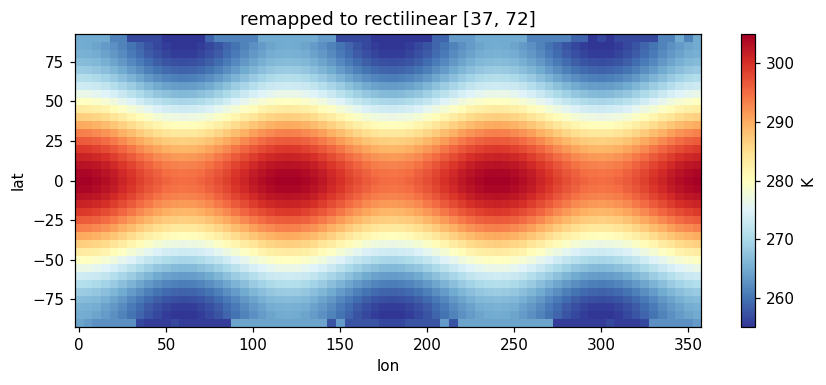

In [15]:
target_lon = np.arange(0, 360, 5.0)
target_lat = np.arange(-90, 91, 5.0)
rr = run_analysis(
    operation="remap_to_rectilinear",
    grid_path=GRID,
    data_path=DATA,
    variable_name="temperature",
    target_lon=list(target_lon),
    target_lat=list(target_lat),
)
show("remap_to_rectilinear — stats", rr)

# Reproduce the regular grid for display
da = ux.open_dataset(GRID, DATA)["temperature"]
rect = da.remap.to_rectilinear(lon=target_lon, lat=target_lat)
fig, ax = plt.subplots(figsize=(8, 3.6))
im = ax.pcolormesh(
    target_lon, target_lat, np.asarray(rect.values), cmap="RdYlBu_r", shading="auto"
)
ax.set_title(f"remapped to rectilinear {rr['target_shape']}")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
fig.colorbar(im, ax=ax, label="K")
fig.tight_layout()
show_fig(fig)

## 2.9 Zonal mean profile — through the plotting tool

The package renders this directly as a base64 PNG.

zonal-mean temperature profile  (29,371 bytes)


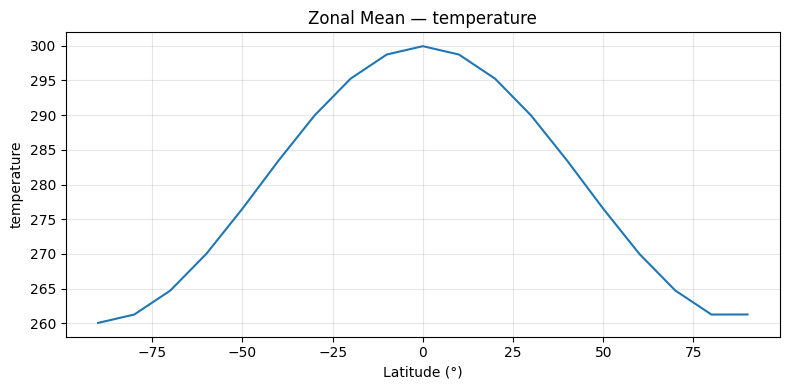

In [16]:
show_png(
    plot_dataset(
        plot_type="zonal_mean",
        grid_path=GRID,
        data_path=DATA,
        variable_name="temperature",
    ),
    "zonal-mean temperature profile",
)

---
# Part 3 — PR #65: guided science-workflow prompts

These *prompt-as-tool* helpers under the `prompt/` namespace don't compute —
they return ready-to-run instruction text that chains the operations above
into a full analysis. An AI agent reads the text and executes the steps.

In [17]:
from uxarray_mcp.registry import (
    climatology_anomaly,
    cyclone_structure,
    eddy_activity,
    model_evaluation,
)

print(
    cyclone_structure(
        GRID, DATA, "temperature", center_lon=0.0, center_lat=0.0, u_var="u", v_var="v"
    )
)

Characterise the cyclone/vortex near (0.0, 0.0) in `/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/data.nc`.

1. Call `run_analysis` with operation="azimuthal_mean", grid_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc", data_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/data.nc", variable_name="temperature", center_lon=0.0, center_lat=0.0, outer_radius=10.0, radius_step=0.5 to build the radial profile.
2. Call `run_analysis` with operation="subset_bbox", grid_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc", data_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/data.nc", variable_name="temperature", lon_bounds=[-10.0, 10.0], lat_bounds=[-10.0, 10.0] to isolate the storm region.
3. Call `run_analysis` with operation="curl", grid_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc", data_path="/var/folders/_f/dc

In [18]:
print(eddy_activity(GRID, DATA, "temperature"))

Assess eddy/wave activity for `temperature` in `/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/data.nc`.

1. Call `run_analysis` with operation="calculate_zonal_mean", grid_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc", data_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/data.nc", variable_name="temperature" to establish the latitudinal background state.
2. Call `run_analysis` with operation="zonal_anomaly", grid_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc", data_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/data.nc", variable_name="temperature" to isolate departures from each latitude band (the eddy field).
3. Call `run_analysis` with operation="gradient", grid_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc", data_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/data.nc"

In [19]:
print(model_evaluation(GRID, MODEL, OBS, "temperature"))

Evaluate `temperature` in `/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/model.nc` against reference `/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/obs.nc`.

1. Call `run_analysis` with operation="bias", grid_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc", data_path_a="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/model.nc", data_path_b="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/obs.nc", variable_name="temperature" for the mean signed error.
2. Call `run_analysis` with operation="rmse", grid_path="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/grid.nc", data_path_a="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/model.nc", data_path_b="/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_wfv8rkfc/obs.nc", variable_name="temperature" for the magnitude of the error.
3. Call `run_analysis` with operation="pa

In [ ]:
print(climatology_anomaly(DATA, "temperature", grid_path=GRID))

---
# Part 4 — Discovery + policy tags

The `deferred-full` profile loads ~58 tools but exposes only the core set;
the rest are found via BM25 `discover_tools`. The new ops are discoverable.

In [20]:
discover = full.get_callable("discover_tools")
for q in [
    "compute vorticity wind curl",
    "zonal anomaly eddy departure",
    "compare model and observations bias rmse",
    "remap to a regular lon lat grid",
    "climatology time mean anomaly",
]:
    print(f"\n'{q}'")
    for r in discover(query=q, top_k=3):
        tag = "[deferred]" if r.get("deferred") else "[core]    "
        print(f"  {tag} {r['name']}")


'compute vorticity wind curl'
  [deferred] compute-calculate_curl
  [deferred] compute-calculate_divergence
  [core]     prompt-cyclone_structure

'zonal anomaly eddy departure'
  [deferred] compute-calculate_zonal_anomaly
  [core]     prompt-eddy_activity
  [deferred] compute-calculate_anomaly

'compare model and observations bias rmse'
  [core]     prompt-model_evaluation
  [core]     run_analysis
  [deferred] compute-compare_fields

'remap to a regular lon lat grid'
  [deferred] shape-remap_to_rectilinear
  [deferred] shape-remap_variable
  [deferred] shape-regrid_dataset

'climatology time mean anomaly'
  [core]     prompt-climatology_anomaly
  [deferred] compute-calculate_temporal_mean
  [deferred] compute-calculate_anomaly


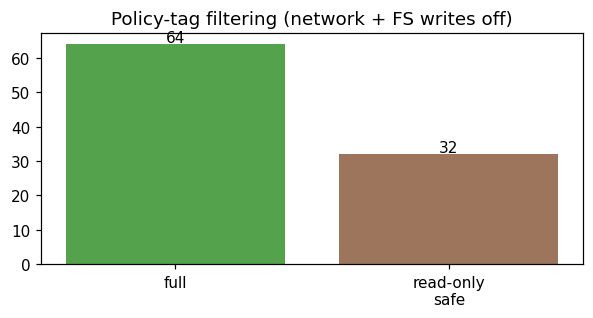

In [21]:
from toolregistry import ToolTag

safe = make_registry(profile="deferred-full")
safe.disable_by_tags([ToolTag.NETWORK, ToolTag.FILE_SYSTEM])
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.bar(
    ["full", "read-only\nsafe"],
    [len(full.list_tools()), len(safe.list_tools())],
    color=["#54a24b", "#9d755d"],
)
ax.set_title("Policy-tag filtering (network + FS writes off)")
for i, vv in enumerate([len(full.list_tools()), len(safe.list_tools())]):
    ax.text(i, vv + 0.5, str(vv), ha="center")
fig.tight_layout()
show_fig(fig)

---
# Part 5 — Native mesh wireframe

`plot_dataset(plot_type="mesh")` renders the unstructured grid itself.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

mesh wireframe  (11,693 bytes)


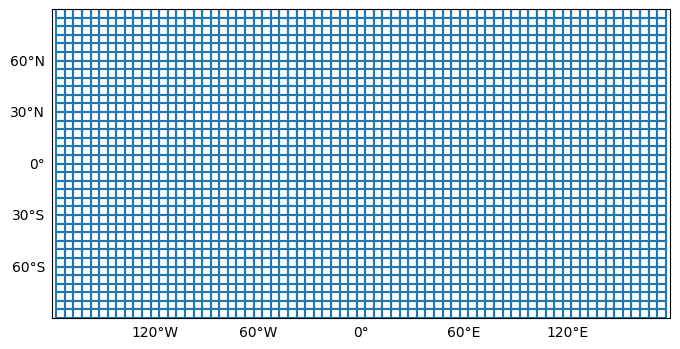

In [22]:
show_png(
    plot_dataset(plot_type="mesh", grid_path=GRID, width=720, height=360),
    "mesh wireframe",
)

---
# Part 6 — Running on HPC: Chrysalis (Argonne LCRC)

The same `run_analysis` calls work on a remote HPC cluster — just add
`use_remote=True, endpoint="chrysalis"`. The data stays on the cluster
filesystem; only the JSON result comes back. This section runs live against
the Chrysalis Globus Compute endpoint using real MPAS meshes.

In [23]:
from uxarray_mcp.tools.frontdoor import diagnose_endpoint

ep = diagnose_endpoint(action="status", endpoint="chrysalis")
ep_info = ep["endpoints"][0]
print(f"endpoint : {ep_info['endpoint_name']}")
print(f"status   : {ep_info['status']}")
print(f"node     : {ep_info['node']}")
print(f"python   : {ep_info['python']}")
print(f"slurm job: {ep_info['slurm_job_id']}")

endpoint : chrysalis
status   : active
node     : chr-0494
python   : 3.12.13
slurm job: 1240620


## 6.1 Remote inspect + area on MPAS QU 480km

In [24]:
import time as _time

MPAS_GRID = "/home/jain/uxarray/test/meshfiles/mpas/QU/480/grid.nc"
MPAS_DATA = "/home/jain/uxarray/test/meshfiles/mpas/QU/480/data.nc"

t0 = _time.time()
mesh = run_analysis(
    operation="inspect_mesh", grid_path=MPAS_GRID, use_remote=True, endpoint="chrysalis"
)
show(f"remote inspect_mesh ({_time.time() - t0:.1f}s)", mesh)

t0 = _time.time()
area = run_analysis(
    operation="calculate_area",
    grid_path=MPAS_GRID,
    use_remote=True,
    endpoint="chrysalis",
)
show(f"remote calculate_area ({_time.time() - t0:.1f}s)", area)

=== remote inspect_mesh (37.6s) ===
{
  "n_face": 1791,
  "n_node": 3947,
  "n_edge": 5754,
  "source": "/home/jain/uxarray/test/meshfiles/mpas/QU/480/grid.nc"
}

=== remote calculate_area (11.0s) ===
{
  "total_area": 8.806940132593539,
  "mean_area": 0.0049173311739774085,
  "min_area": 0.0038025853747529854,
  "max_area": 0.005064221670790574,
  "area_units": "m^2",
  "n_face": 1791
}



## 6.2 Remote vector calculus on MPAS dyamond-30km

In [25]:
DYA_GRID = "/home/jain/uxarray/test/meshfiles/mpas/dyamond-30km/gradient_grid_subset.nc"
DYA_DATA = "/home/jain/uxarray/test/meshfiles/mpas/dyamond-30km/gradient_data_subset.nc"

t0 = _time.time()
grad = run_analysis(
    operation="gradient",
    grid_path=DYA_GRID,
    data_path=DYA_DATA,
    variable_name="gaussian",
    use_remote=True,
    endpoint="chrysalis",
)
show(f"remote gradient ({_time.time() - t0:.1f}s)", grad)

t0 = _time.time()
curl = run_analysis(
    operation="curl",
    grid_path=DYA_GRID,
    data_path=DYA_DATA,
    u_variable="gaussian",
    v_variable="inverse_gaussian",
    use_remote=True,
    endpoint="chrysalis",
)
show(f"remote curl / vorticity ({_time.time() - t0:.1f}s)", curl)

t0 = _time.time()
div = run_analysis(
    operation="divergence",
    grid_path=DYA_GRID,
    data_path=DYA_DATA,
    u_variable="gaussian",
    v_variable="inverse_gaussian",
    use_remote=True,
    endpoint="chrysalis",
)
show(f"remote divergence ({_time.time() - t0:.1f}s)", div)

=== remote gradient (11.0s) ===
{
  "variable_name": "gaussian",
  "components": [
    "zonal_gradient",
    "meridional_gradient"
  ],
  "component_stats": {
    "zonal_gradient": {
      "min": -100.57507767005796,
      "max": 99.91423804026928,
      "mean": 0.6472388996078627
    },
    "meridional_gradient": {
      "min": -101.42013881477544,
      "max": 100.26629278353671,
      "mean": -0.32682765131557107
    }
  },
  "n_face": 195,
  "scale_by_radius": false,
  "interpretation": "zonal (d/dx) and meridional (d/dy) components of the gradient"
}

=== remote curl / vorticity (11.5s) ===
{
  "u_variable": "gaussian",
  "v_variable": "inverse_gaussian",
  "interpretation": "relative vorticity zeta = dv/dx - du/dy",
  "n_face": 195,
  "scale_by_radius": false,
  "stats": {
    "min": -142.31143857024824,
    "max": 142.83018700581528,
    "mean": -0.32041133381699183,
    "std": 86.27243455970452
  }
}

=== remote divergence (2.5s) ===
{
  "u_variable": "gaussian",
  "v_variable"

## 6.3 Remote zonal mean on QU 480km

In [26]:
t0 = _time.time()
zm = run_analysis(
    operation="calculate_zonal_mean",
    grid_path=MPAS_GRID,
    data_path=MPAS_DATA,
    variable_name="bottomDepth",
    use_remote=True,
    endpoint="chrysalis",
)
show(f"remote zonal mean ({_time.time() - t0:.1f}s)", zm)

=== remote zonal mean (1.0s) ===
{
  "variable_name": "bottomDepth",
  "latitudes": [
    -90.0,
    -80.0,
    -70.0,
    -60.0,
    -50.0,
    -40.0,
    -30.0,
    -20.0,
    -10.0,
    0.0,
    10.0,
    20.0,
    30.0,
    40.0,
    50.0,
    60.0,
    70.0,
    80.0,
    90.0
  ],
  "zonal_mean_values": [
    NaN,
    NaN,
    3370.346341225356,
    4185.856918639845,
    3585.586579492889,
    4111.816268458646,
    3827.0999292732863,
    3693.730598641159,
    3727.1174694946208,
    3550.662376325325,
    3816.808920752031,
    3889.8124613685995,
    4158.674053410319,
    4401.079265722941,
    3169.3956417513014,
    1360.8054257892193,
    658.4428168554853,
    1542.17730132307,
    4123.0
  ],
  "conservative": false,
  "grid_info": {
    "n_face": 1791,
    "n_node": 3947,
    "n_edge": 5754
  }
}



## 6.4 Timing summary

Warm round-trips (worker already running) are typically 0.5–5s for these
mesh sizes. Cold start (PBS scheduler spins up a new worker) can take 3–4
minutes. The `diagnose_endpoint(action="status")` call above confirms the
worker is live before submitting work.

---
## Summary

| What's new | How to reach it |
|---|---|
| **PR #64** App foundation | `from uxarray_mcp.app import make_registry, make_mcp_server, UXarrayApp` |
| **PR #64** REST/OpenAPI | `uxarray-mcp openapi --port 8000` · `app.serve_openapi(...)` |
| **PR #65** vector calculus | `run_analysis(operation="gradient"\|"curl"\|"divergence", ...)` |
| **PR #65** azimuthal mean | `run_analysis(operation="azimuthal_mean", center_lon=, center_lat=, ...)` |
| **PR #65** zonal anomaly | `run_analysis(operation="zonal_anomaly", ...)` |
| **PR #65** verification | `run_analysis(operation="bias"\|"rmse"\|"pattern_correlation", ...)` |
| **PR #65** climatology | `run_analysis(operation="temporal_mean"\|"anomaly", ...)` |
| **PR #65** rectilinear remap | `run_analysis(operation="remap_to_rectilinear", target_lon=, target_lat=)` |
| **PR #65** science prompts | `prompt/cyclone_structure`, `eddy_activity`, `model_evaluation`, `climatology_anomaly` |
| **HPC** Chrysalis remote | Same calls + `use_remote=True, endpoint="chrysalis"` |

Everything above is the *same* code path an MCP/AI client or the OpenAPI
server uses — only the transport differs.